In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"


In [60]:
df=pd.read_csv(url)

In [61]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [62]:
x=df["horsepower"]
y=df["mpg"]

In [63]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [64]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


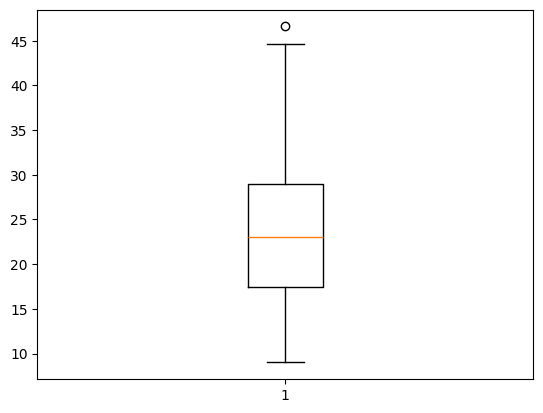

In [68]:
plt.boxplot(df["mpg"].dropna())
plt.show()

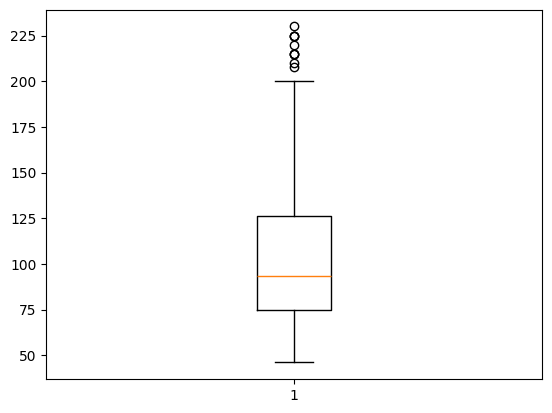

In [69]:
plt.boxplot(df["horsepower"].dropna())
plt.show()

In [70]:
Q1=df["horsepower"].quantile(0.25)
Q3=df["horsepower"].quantile(0.75)
IQR=Q3-Q1

outliers=df[(df["horsepower"]<Q1-1.5*IQR)|(df["horsepower"]>Q3+1.5*IQR)]
print(outliers)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
6    14.0          8         454.0       220.0    4354           9.0   
7    14.0          8         440.0       215.0    4312           8.5   
8    14.0          8         455.0       225.0    4425          10.0   
13   14.0          8         455.0       225.0    3086          10.0   
25   10.0          8         360.0       215.0    4615          14.0   
27   11.0          8         318.0       210.0    4382          13.5   
67   11.0          8         429.0       208.0    4633          11.0   
94   13.0          8         440.0       215.0    4735          11.0   
95   12.0          8         455.0       225.0    4951          11.0   
116  16.0          8         400.0       230.0    4278           9.5   

     model_year origin                          name  
6            70    usa              chevrolet impala  
7            70    usa             plymouth fury iii  
8            70    usa              pontia

In [71]:
Q1=df["mpg"].quantile(0.25)
Q3=df["mpg"].quantile(0.75)
IQR=Q3-Q1

outliers=df[(df["mpg"]<Q1-1.5*IQR)|(df["mpg"]>Q3+1.5*IQR)]
print(outliers)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
322  46.6          4          86.0        65.0    2110          17.9   

     model_year origin       name  
322          80  japan  mazda glc  


In [72]:
df.shape

(398, 9)

In [73]:
df=df.dropna(subset=["horsepower",])

In [74]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [75]:
x_mean=np.mean(x)
y_mean=np.mean(y)

numerator=np.sum((x-x_mean)*(y-y_mean))
denominator=np.sum((x-x_mean)**2)

w=numerator/denominator
b=y_mean-w*x_mean
y_pred=w*x+b

slope (w): -0.15784473335365362
intercept (b): 40.00451551814514


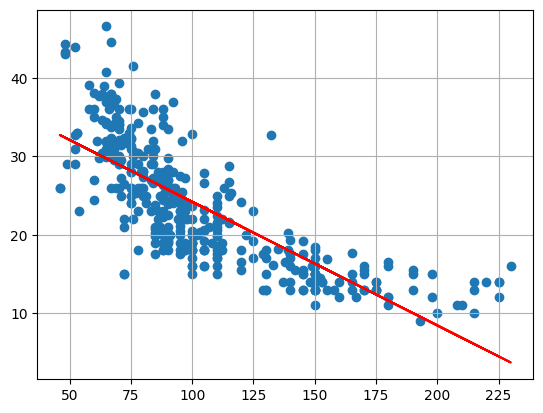

In [76]:
print("slope (w):",w)
print("intercept (b):",b)

plt.scatter(x,y)
plt.plot(x,y_pred,color='red')
plt.grid(True)
plt.show()

In [77]:
df.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 30.6 KB


In [78]:
model = LinearRegression()
x = df[['horsepower']]
y = df['mpg']
model.fit(x,y)

print("intercept", model.intercept_)
print("slope:", model.coef_[0])

intercept 39.93586102117047
slope: -0.15784473335365365
